
# 1. CONFIGURATION

In [ ]:
import zipfile
import os

# Path to your zip file (Update this if you used Google Drive)
# If you used Method A (Direct Upload), it's just '/content/data.zip'
zip_path = '/content/data.zip'

# Unzip it
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Files unzipped!")

Files unzipped!


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
img_rows, img_cols = 224, 224
num_classes = 7
batch_size = 32
epochs_warmup = 10   # Phase 1
epochs_finetune = 35 # Phase 2

# Check your paths!
train_data_dir = '/content/dataset/data/train'
validation_data_dir = '/content/dataset/data/val'

print(f"TensorFlow Version: {tf.__version__}")
print(f"Training Data: {train_data_dir}")
print(f"Validation Data: {validation_data_dir}")


TensorFlow Version: 2.19.0
Training Data: /content/dataset/data/train
Validation Data: /content/dataset/data/val


# 2. DATA PREPARATION


In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator() # No parameters, no rescaling

print("\nLoading Data...")
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical'
)


Loading Data...
Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# 3. MODEL ARCHITECTURE


In [ ]:
print("\nBuilding EfficientNetB0 Model...")

# Load Base Model (Frozen)
base_model = EfficientNetB0(weights='imagenet',
                            include_top=False,
                            input_shape=(img_rows, img_cols, 3))

# Freeze base layers for Phase 1
for layer in base_model.layers:
    layer.trainable = False

# Custom Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x) # Reduce overfitting
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile for Warmup
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

print(model.summary())


Building EfficientNetB0 Model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,368,490 (20.48 MB)

 Trainable params: 1,318,919 (5.03 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

None


# 4. PHASE 1: WARM UP (Head Only)


In [ ]:
print("\n=== PHASE 1: Warm Up (Training Top Layers) ===")

history_warmup = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs_warmup,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)



=== PHASE 1: Warm Up (Training Top Layers) ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 430s 444ms/step - accuracy: 0.2995 - loss: 1.7517 - val_accuracy: 0.3687 - val_loss: 1.6036
Epoch 2/10
  1/897 ━━━━━━━━━━━━━━━━━━━━ 30s 34ms/step - accuracy: 0.5000 - loss: 1.5114

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


897/897 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.5000 - loss: 1.5114 - val_accuracy: 0.3680 - val_loss: 1.6028
Epoch 3/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 376s 419ms/step - accuracy: 0.3534 - loss: 1.6199 - val_accuracy: 0.3756 - val_loss: 1.5925
Epoch 4/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4688 - loss: 1.5387 - val_accuracy: 0.3767 - val_loss: 1.5929
Epoch 5/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 430s 417ms/step - accuracy: 0.3768 - loss: 1.5815 - val_accuracy: 0.4039 - val_loss: 1.5368
Epoch 6/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4375 - loss: 1.3438 - val_accuracy: 0.4043 - val_loss: 1.5351
Epoch 7/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 371s 414ms/step - accuracy: 0.3904 - loss: 1.5650 - val_accuracy: 0.3855 - val_loss: 1.5561
Epoch 8/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.4688 - loss: 1.3283 - val_accuracy: 0.3839 - val_loss: 1.5573
Epoch 9/10
897/897 ━━━━━━━━━━━━━━━━━━━━ 371s 414ms/step - accuracy: 0.3883 - loss: 1.5609 - val_acc

# 5. PHASE 2: FINE TUNING (Whole Model)


In [ ]:
print("\n=== PHASE 2: Fine Tuning (Unfreezing Layers) ===")

# Unfreeze all layers
for layer in base_model.layers:
    layer.trainable = True

# Define Callbacks
checkpoint = ModelCheckpoint(
    'emotion_efficientnet_b0.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, earlystop, reduce_lr]

# Re-compile with LOW learning rate
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=0.0001),
              metrics=['accuracy'])

history_finetune = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs_finetune,
    callbacks=callbacks,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)


=== PHASE 2: Fine Tuning (Unfreezing Layers) ===
Epoch 1/35
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.3659 - loss: 1.7827
Epoch 1: val_accuracy improved from -inf to 0.50460, saving model to emotion_efficientnet_b0.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 538s 509ms/step - accuracy: 0.3660 - loss: 1.7824 - val_accuracy: 0.5046 - val_loss: 1.2956 - learning_rate: 1.0000e-04
Epoch 2/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:50 123ms/step - accuracy: 0.4688 - loss: 1.2412
Epoch 2: val_accuracy did not improve from 0.50460
897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4688 - loss: 1.2412 - val_accuracy: 0.5032 - val_loss: 1.2959 - learning_rate: 1.0000e-04
Epoch 3/35
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.5205 - loss: 1.2624
Epoch 3: val_accuracy improved from 0.50460 to 0.57533, saving model to emotion_efficientnet_b0.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 442s 493ms/step - accuracy: 0.5206 - loss: 1.2623 - val_accuracy: 0.5753 - val_loss: 1.1164 - learning_rate: 1.0000e-04
Epoch 4/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:45 118ms/step - accuracy: 0.6562 - loss: 1.1021
Epoch 4: val_accuracy improved from 0.57533 to 0.57603, saving model to emotion_efficientnet_b0.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6562 - loss: 1.1021 - val_accuracy: 0.5760 - val_loss: 1.1162 - learning_rate: 1.0000e-04
Epoch 5/35
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.5813 - loss: 1.1211
Epoch 5: val_accuracy improved from 0.57603 to 0.60896, saving model to emotion_efficientnet_b0.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 405s 452ms/step - accuracy: 0.5813 - loss: 1.1210 - val_accuracy: 0.6090 - val_loss: 1.0458 - learning_rate: 1.0000e-04
Epoch 6/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:49 122ms/step - accuracy: 0.5938 - loss: 1.2186
Epoch 6: val_accuracy improved from 0.60896 to 0.61021, saving model to emotion_efficientnet_b0.h5


...

897/897 ━━━━━━━━━━━━━━━━━━━━ 410s 456ms/step - accuracy: 0.7185 - loss: 0.7683 - val_accuracy: 0.6742 - val_loss: 0.9206 - learning_rate: 2.0000e-05
Epoch 18/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:48 121ms/step - accuracy: 0.8125 - loss: 0.6518
Epoch 18: val_accuracy did not improve from 0.67425
897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8125 - loss: 0.6518 - val_accuracy: 0.6741 - val_loss: 0.9201 - learning_rate: 2.0000e-05
Epoch 19/35
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.7206 - loss: 0.7420
Epoch 19: val_accuracy did not improve from 0.67425
897/897 ━━━━━━━━━━━━━━━━━━━━ 404s 451ms/step - accuracy: 0.7206 - loss: 0.7420 - val_accuracy: 0.6735 - val_loss: 0.9427 - learning_rate: 2.0000e-05
Epoch 20/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:53 126ms/step - accuracy: 0.7500 - loss: 0.7940
Epoch 20: val_accuracy did not improve from 0.67425
897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7500 - loss: 0.7940 - val_accuracy: 0.6730 - val_loss: 0.9445 - learning_


Epoch 21: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
897/897 ━━━━━━━━━━━━━━━━━━━━ 436s 454ms/step - accuracy: 0.7255 - loss: 0.7192 - val_accuracy: 0.6795 - val_loss: 0.9326 - learning_rate: 2.0000e-05
Epoch 22/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:45 118ms/step - accuracy: 0.6562 - loss: 0.8554
Epoch 22: val_accuracy improved from 0.67955 to 0.67969, saving model to emotion_efficientnet_b0.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.6562 - loss: 0.8554 - val_accuracy: 0.6797 - val_loss: 0.9316 - learning_rate: 4.0000e-06
Epoch 23/35
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.7383 - loss: 0.6983
Epoch 23: val_accuracy improved from 0.67969 to 0.68192, saving model to emotion_efficientnet_b0.h5


897/897 ━━━━━━━━━━━━━━━━━━━━ 410s 457ms/step - accuracy: 0.7383 - loss: 0.6983 - val_accuracy: 0.6819 - val_loss: 0.9313 - learning_rate: 4.0000e-06
Epoch 24/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:47 120ms/step - accuracy: 0.7500 - loss: 0.5170
Epoch 24: val_accuracy improved from 0.68192 to 0.68234, saving model to emotion_efficientnet_b0.h5



Epoch 24: ReduceLROnPlateau reducing learning rate to 1e-06.
897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7500 - loss: 0.5170 - val_accuracy: 0.6823 - val_loss: 0.9314 - learning_rate: 4.0000e-06
Epoch 25/35
897/897 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.7440 - loss: 0.6933
Epoch 25: val_accuracy did not improve from 0.68234
897/897 ━━━━━━━━━━━━━━━━━━━━ 408s 455ms/step - accuracy: 0.7440 - loss: 0.6933 - val_accuracy: 0.6811 - val_loss: 0.9302 - learning_rate: 1.0000e-06
Epoch 26/35
  1/897 ━━━━━━━━━━━━━━━━━━━━ 1:46 119ms/step - accuracy: 0.7188 - loss: 0.8038
Epoch 26: val_accuracy did not improve from 0.68234
897/897 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7188 - loss: 0.8038 - val_accuracy: 0.6808 - val_loss: 0.9313 - learning_rate: 1.0000e-06
Epoch 26: early stopping
Restoring model weights from the end of the best epoch: 18.


# 6. VISUALIZATION



Plotting Results...


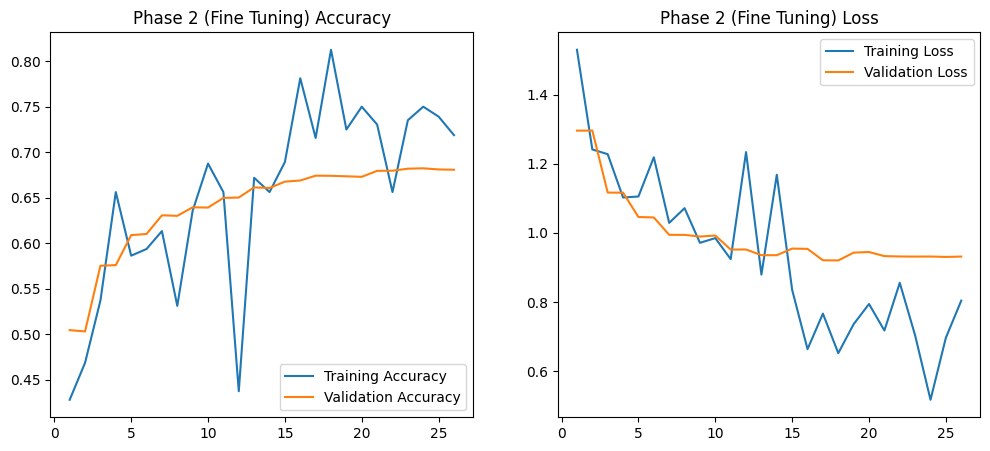

In [ ]:
def plot_history(history, title_prefix=""):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title_prefix} Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title_prefix} Loss')
    plt.legend(loc='upper right')
    plt.show()

print("\nPlotting Results...")
plot_history(history_finetune, "Phase 2 (Fine Tuning)")

# 7. EVALUATION (Confusion Matrix)



Generating Confusion Matrix...
Found 7178 images belonging to 7 classes.
225/225 ━━━━━━━━━━━━━━━━━━━━ 29s 100ms/step


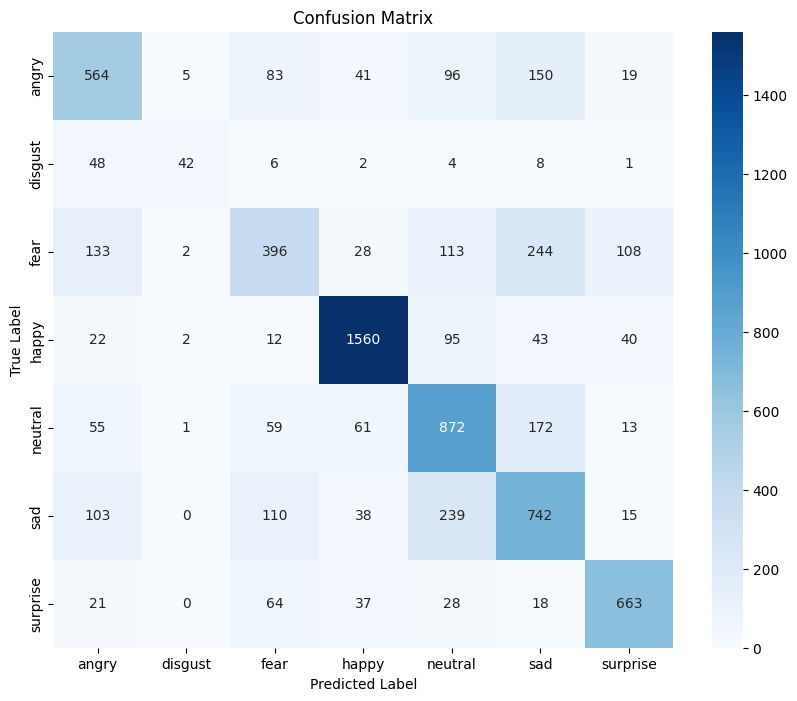


=== Classification Report ===
              precision    recall  f1-score   support

       angry       0.60      0.59      0.59       958
     disgust       0.81      0.38      0.52       111
        fear       0.54      0.39      0.45      1024
       happy       0.88      0.88      0.88      1774
     neutral       0.60      0.71      0.65      1233
         sad       0.54      0.60      0.57      1247
    surprise       0.77      0.80      0.78       831

    accuracy                           0.67      7178
   macro avg       0.68      0.62      0.63      7178
weighted avg       0.67      0.67      0.67      7178



In [ ]:
print("\nGenerating Confusion Matrix...")

# Re-create validation generator with shuffle=False for accurate reporting
eval_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Predict
Y_pred = model.predict(eval_generator, eval_generator.samples // batch_size + 1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = eval_generator.classes[:len(y_pred)]

# Matrix
class_labels = list(eval_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels))